# Conceptual

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Q1.
```{admonition}
:class: note
Consider a neural network with two hidden layers: $p = 4$ input units, $2$ units in the first hidden layer, $3$ units in the second hidden layer, and a single output.

```{admonition}
:class: note
(a) Draw a picture of the network.

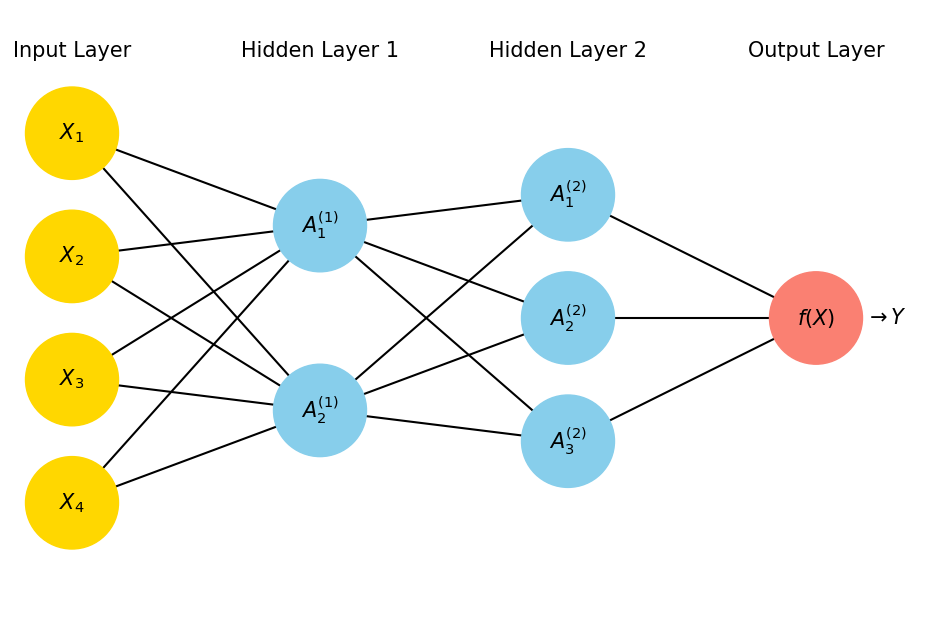

In [8]:
fig, ax = plt.subplots(figsize=(12,8))

sep = 8
xs = np.linspace(0,sep,2)
rad = 1.5

L0 = np.linspace(-6,6,4)[::-1]
L1 = np.linspace(-3,3,2)[::-1]
L2 = np.linspace(-4,4,3)[::-1]
L3 = [0]
labels = L0[0]+sep/3

for i,c0 in enumerate(L0):
    for c1 in L1:
        ax.plot(xs,[c0,c1],'k',zorder=0)
    ax.add_patch(plt.Circle((xs[0],c0),radius=rad,color = 'gold'))
    ax.text(xs[0],c0,f'$X_{i+1}$',ha='center',va='center',fontsize=15)
ax.text(xs[0],labels,'Input Layer',ha='center',va='center',fontsize=15)

xs += sep
for i, c1 in enumerate(L1):
    for c2 in L2:
        ax.plot(xs,[c1,c2],'k',zorder=0)
    ax.add_patch(plt.Circle((xs[0],c1),radius=rad,color='skyblue'))
    ax.text(xs[0],c1,f'$A^{{(1)}}_{i+1}$',ha='center',va='center',fontsize=15)
ax.text(xs[0],labels,'Hidden Layer 1',ha='center',va='center',fontsize=15)

xs += sep
for i, c2 in enumerate(L2):
    ax.plot(xs,[c2,0],'k',zorder=0)
    ax.add_patch(plt.Circle((xs[0],c2),radius=rad,color='skyblue'))
    ax.text(xs[0],c2,f'$A^{{(2)}}_{i+1}$',ha='center',va='center',fontsize=15)
ax.text(xs[0],labels,'Hidden Layer 2',ha='center',va='center',fontsize=15)

xs += sep
ax.add_patch(plt.Circle((xs[0],0),radius=rad,color='salmon'))
ax.text(xs[0],0,f'$f(X)$',ha='center',va='center',fontsize=15)
ax.text(xs[0],labels,'Output Layer',ha='center',va='center',fontsize=15)

ax.text(xs[0]+sep*0.28,0,r'$\to Y$',ha='center',va='center',fontsize=15)

ax.set_xlim(-2,28)
ax.set_ylim(-10,10)
ax.set_axis_off()
plt.show()

```{admonition}
:class: note
(b) Write out an expression for $f(X)$, assuming ReLU activation functions. Be as explicit as you can!

$$
f(X) = \beta_{0}+\sum_{k=1}^{3}\beta_{k}A_{k}^{(2)}
= \beta_{0}+\sum_{k=1}^{3}\beta_{k}\operatorname{ReLU}\left(w_{k0}^{(2)}+\sum_{j=1}^{2}w_{kj}^{(2)}A_{j}^{(1)}\right)
= \beta_{0}+\sum_{k=1}^{3}\beta_{k}\operatorname{ReLU}\left(w_{k0}^{(2)}+\sum_{j=1}^{2}w_{kj}^{(2)}\operatorname{ReLU}\left(w_{j0}^{(1)}+\sum_{i=1}^{4} w_{ji}^{(1)}X_{i}\right)\right)
$$

```{admonition}
:class: note
(c) Now plug in some values for the coefficients and write out the value of $f(X)$.

Assume all coefficients are $0$. Then $f(0,0,0,0) = 0$.

```{admonition}
:class: note
(d) How many parameters are there?

The first layer has $10 = 5\cdot 2$ parameters, the second layer has $9 = 3\cdot 3$ parameters, and the output layer has $4$ parameters. This gives $23$ total parameters.

## Q2.
```{admonition}
:class: note
Consider the softmax function in for modeling multinomial probabilities.

```{admonition}
:class: note
(a) In
$$
\frac{e^{Z_{m}}}{\sum_{\ell=0}^{N} e^{Z_{\ell}}},
$$
show that if we add a constant $c$ to each of the $Z_{\ell}$, then the probability is unchanged.

We see 
$$
\frac{e^{Z_{m}+c}}{\sum_{\ell=0}^{N} e^{Z_{\ell}+c}} = \frac{e^{Z_{m}}e^{c}}{\sum_{\ell=0}^{N} e^{Z_{\ell}}e^{c}} = \frac{e^{Z_{m}}}{\sum_{\ell=0}^{N} e^{Z_{\ell}}},
$$
so the probability is invariant under shifts.

```{admonition}
:class: note
(b) In
$$
\frac{e^{\beta_{k0}+\beta_{k1}x_{1}+\cdots+\beta_{kp}x_{p}}}{\sum_{l=1}^{K} e^{\beta_{l0}+\beta_{l1}x_{1}+\cdots+\beta_{lp}x_{p}}},
$$
show that if we add constants $c_{j}$ for $j = 0, 1, \dots, p$ to each of the corresponding coefficients for each of the classes, then the predictions at any new point $x$ are unchanged.

Write the expression as
$$
\frac{e^{\langle \beta_{k}, x\rangle}}{\sum_{l=1}^{K} e^{\langle \beta_{l}, x\rangle}}.
$$
Adding constants to the coefficients is the same as adding a constant vector $c$ to every $\beta_{l}$. This gives, using linearity of the inner product,
$$
\frac{e^{\langle \beta_{k}+c, x\rangle}}{\sum_{l=1}^{K} e^{\langle \beta_{l}+c, x\rangle}}
= \frac{e^{\langle \beta_{k}, x\rangle+\langle c , x\rangle}}{\sum_{l=1}^{K} e^{\langle \beta_{l}, x\rangle+\langle c , x\rangle}}
= \frac{e^{\langle \beta_{k}, x\rangle}e^{\langle c , x\rangle}}{\sum_{l=1}^{K} e^{\langle \beta_{l}, x\rangle}e^{\langle c , x\rangle}}
= \frac{e^{\langle \beta_{k}, x\rangle}}{\sum_{l=1}^{K} e^{\langle \beta_{l}, x\rangle}}.
$$

Therefore the probability is invariant under shifts and any predictions would remain unchanged.

## Q3. 
```{admonition}
:class: note
Show that the negative multinomial log-likelihood is equivalent to the negative log of the likelihood expression when there are $M = 2$ classes.

With two classes, the multinomial log-likelihood is
$$
\sum_{i=1}^{n}\left(y_{i0}\log(f_{0}(x_{i}))+y_{i1}\log(f_{1}(x_{i}))\right)
$$

and the likelihood expression is
$$
\ell(\beta_{0},\beta_{1}) = \prod_{i:y_{i}=1} p(x_{i}) \prod_{i':y_{i'}=0}(1-p(x_{i'}))
$$

The log of the likelihood is
$$
\log\left(\prod_{i:y_{i}=1} p(x_{i}) \prod_{i':y_{i'}=0}(1-p(x_{i'}))\right)
= \sum_{i:y_{i}=1} \log(p(x_{i})) + \sum_{i':y_{i'}=0} \log(1-p(x_{i'}))
= \sum_{i=1}^{n} \left([y_{i}=1]\log(p(x_{i})) + [y_{i}=0]\log(1-p(x_{i}))\right).
$$

Recall that the $y_{ij}$ are 0-1 indicators for the class label, which is what $[y_{i}=j]$ represents. Noting that $f_{j}(x_{i})$ are the probabilites, and given there are two classes they are complimentary, we see this expression can be further rewritten as
$$
\sum_{i=1}^{n} \left(y_{i1}\log(p(x_{i})) + y_{i0}\log(1-p(x_{i}))\right) = \sum_{i=1}^{n} \left(y_{i1}\log(f_{1}(x_{i})) + y_{i0}\log(f_{0}(x_{i}))\right).
$$

Multiplying this and the multinomial log-likelihood by $-1$ gives the needed equivalence.

## Q4.
```{admonition}
:class: note
Consider a CNN that takes in $32 \times 32$ grayscale images and has a single convolution layer with three $5 \times 5$ convolution filters (without boundary padding).

```{admonition}
:class: note
(a) Draw a sketch of the input and first hidden layer.

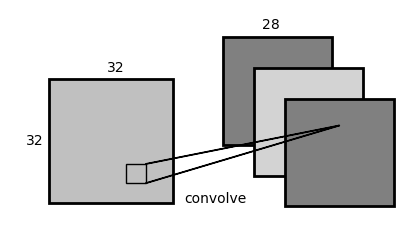

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))

input_box = ax.add_patch(plt.Rectangle((.1, .1), 0.32, 0.32,linewidth=2,edgecolor='black',facecolor='silver'))

conv_select = ax.add_patch(plt.Rectangle((.3, .15), 0.05, 0.05,linewidth=1,edgecolor='black',facecolor='silver'))

ax.text(0.04, 0.25, '32')
ax.text(0.25, 0.44, '32')

ax.arrow(0.35, 0.15, 0.5, 0.15, head_width=0, head_length=0, fc='black', ec='black',zorder=5)
ax.arrow(0.35, 0.2, 0.5, 0.1, head_width=0, head_length=0, fc='black', ec='black',zorder=5)

colors = ['gray', 'lightgray', 'gray']
for i in range(3):
    ax.add_patch(plt.Rectangle((.55 + i*0.08, 0.25 - i*0.08), 0.28, 0.28,linewidth=2,edgecolor='black',facecolor=colors[i]))

ax.text(0.65, 0.55, '28')
ax.text(0.45, 0.1, 'convolve')

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.6)
ax.axis('off')

plt.show()

```{admonition}
:class: note
(b) How many parameters are in this model?

With bias, each convolution filter has $5\cdot 5 +1 = 26$ parameters. Therefore there are $3\cdot 26 = 78$ total parameters in the model.

```{admonition}
:class: note
(c) Explain how this model can be thought of as an ordinary feed-forward neural network with the individual pixels as inputs, and with constraints on the weights in the hidden units. What are the constraints?

We can feed in each individual pixel subject to locality and weight sharing constraints. To recover the convolution filter being a $5\times 5$ grid, the hidden unit is only given a $25$ unit patch. To keep the filter consistant across the entire image, the hidden units corresponding to a given filter share the same weights.

```{admonition}
:class: note
(d) If there were no constraints, then how many weights would there be in the ordinary feed-forward neural network in (c)?

The input is of size $32\cdot32=1024$ and without constraints the convolution filters have $28\cdot 28\cdot 3 = 2352$ weights. This gives $2\,408\,448$ total weights.

## Q5.
```{admonition}
:class: note
In the table below, we see that the ordering of the three methods with respect to mean absolute error is different from the ordering with respect to test set $R^{2}$. How can this be?
    
|      Model       | # Parameters| Mean Abs. Error | Test Set $R^2$ |
|------------------|------------:|----------------:|---------------:|
| Linear Regression|     20      |       254.7     |        0.56    |
| Lassso           |     12      |       252.3     |        0.51    |
| Neural Network   |     1345    |       257.4     |        0.54    |


The $R^{2}$ value uses mean squared error in its calculation and is more sensitive to outliers. The lasso model could have generally small errors with several outliers, while the regression model is making larger errors but with fewer outliers.